cleaning up all over again

In [1]:
pwd

'/'

In [2]:
cd Users/ibehbehani/csm_pipeline/

/Users/ibehbehani/csm_pipeline


In [3]:
ls

README.md                         lowmed.ipynb
__pycache__/                      medhigh copy.ipynb
abel.py                           medhigh.ipynb
abel_mass_loss_title.png          medhigh_abel.ipynb
align_and_diff.py                 medhigh_abel_interpolation.ipynb
blanktest.ipynb                   medhigh_abel_template.ipynb
conv_reproj.py                    pandas.ipynb
corrected_abel/                   pm.py
csm_2d_jy_arc2.csv                radial.py
csm_densities.csv                 radial_data_val.ipynb
csm_radii.csv                     radial_density_polar.ipynb
data_val_azimuthal_old.ipynb      radial_interpolation.py
data_val_azimuthal_radial.ipynb   rays.ipynb
dens.py                           rays_via_polar.ipynb
everything.py                     rays_via_polar_first_draft.ipynb
header_setup.py                   star_densities.csv
hroriginal.png                    star_radii.csv
iat_mass_loss.png                 template.ipynb
interp.ipynb                      thesis/
lowh

In [4]:
less radial_interpolation.py

'''
Procedure for radial interpolation of a 2d dataset

'''

import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from scipy.interpolate import RectBivariateSpline

print("hello")

def radial_interp(image, cx,cy, n_lines, n_pts, plot=True):
    '''
    runs radial interpolation sequence
    plots resulting comparison

    returns:
    Plots comparison of original image and interpolated image
    x_vals: x value grid where each row corresponds to the x values along a given ray
    y_vals: y value grid where ... y values along a given ray
    interp_star: grad where rows correspond to interpolated values along a given ray
    '''
    x_vals,y_vals,interp_star = ray_calculation(image, cx,cy, n_lines, n_pts, plot=True)
    return x_vals,y_vals,interp_star

def make_spline(x,y,image):
    '''
    makes RectBivariateSpline for your 2d dataset 
    returns spline
    '''
    spline = RectBivariateSpline(x,y,image) # making function to interpolate starry array

In [5]:
import csv

csm_2d_intensity_list = []
with open("csm_2d_jy_arc2.csv") as csvfile:
    reader = csv.reader(csvfile, quoting=csv.QUOTE_NONNUMERIC) # change contents to floats
    for row in reader: # each row is a list
        csm_2d_intensity_list.append(row)

In [6]:
from conv_reproj import match
from align_and_diff import a_d
from header_setup import read

from matplotlib import pyplot as plt
import numpy as np

from astropy.io import fits
from pm import pm_correct
from astropy import units as u
from astropy.wcs import WCS
import cmasher as cmr

from astropy.time import Time
from astropy.coordinates import SkyCoord

Match function imported.
running


In [7]:
from everything import full_analysis
from everything import plot_1d, plot_2d
from radial import radial_read
from dens import density_model

Ready to go!


/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
csm_2d_intensity = np.array(csm_2d_intensity_list)
csm_2d_intensity.shape

(1000, 1000)

In [9]:
cx = 499
cy = 499
pix_size_arcsec = 0.005*u.arcsec

Text(0, 0.5, '$\\Delta$ Dec (arc)')

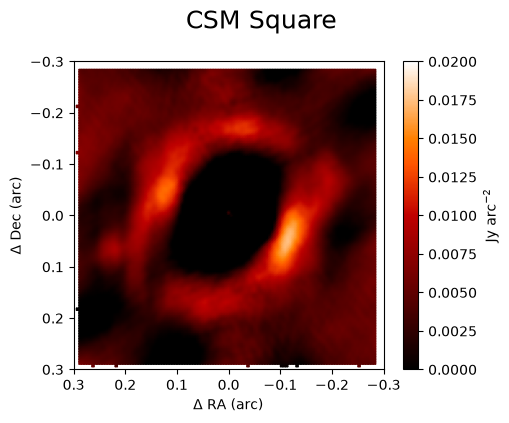

In [10]:
maxx= -0.3
minn = -1*maxx

figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

xaxis = range(csm_2d_intensity.shape[0])*pix_size_arcsec-(cx*pix_size_arcsec)
yaxis = range(csm_2d_intensity.shape[1])*pix_size_arcsec-(cy*pix_size_arcsec)

im = ax.pcolormesh(yaxis,xaxis,csm_2d_intensity, cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.02)

ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

# Finding Rays

Now take resulting 2d surface density image, calculate azumuthal radial profiles to then apply an inverse abel transform to

In [11]:
## CUT IF ON HOME COMPUTER

In [12]:
cd /Users/ibehbehani/csm_pipeline

/Users/ibehbehani/csm_pipeline


In [13]:
from radial_interpolation import *

hello


AttributeError: 'numpy.ndarray' object has no attribute 'value'

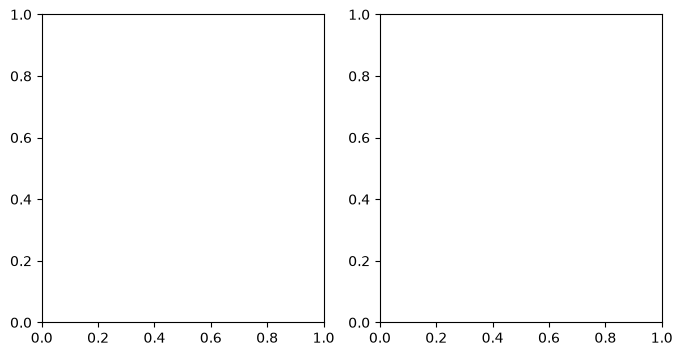

In [14]:
x_grid,y_grid,interp_csm = radial_interp(csm_2d_intensity, cx,cy,
              n_lines = 200, n_pts = 100,plot=False)

## Abel transform

In [ ]:
from abel import all_abel, do_abel, plot_1d_abel

In [ ]:
d = {'hr': data_dens_1d3['hr'], 'lr': data_dens_1d3['lr'], 'reproj': data_dens_1d3['reproj'],"csm": data_dens_1d3['csm']}
i = {'hr': info3['hr'], 'lr': info3['lr'], 'reproj': info3['reproj'],"csm": info3['csm']}

In [ ]:
print(info3['hr']['median'])
print(info3['reproj']['median'])
print(info3['lr']['median'])
print(info3['csm']['median'])


2.7049269580517033e-05
8.418014260236199e-05
0.0010701067859508304
0.0044229718265451756


In [ ]:
print(info3['hr']['median_dens'])
print(info3['reproj']['median_dens'])
print(info3['lr']['median_dens'])
print(info3['csm']['median_dens'])


8.773863086349733e-07 g / cm2
1.493734508648048e-06 g / cm2
6.603274608302551e-05 g / cm2
8.705565119122754e-05 g / cm2


In [ ]:
csm_bkg = np.sqrt(info3['reproj']['median_dens']**2+info3['lr']['median_dens']**2)

In [ ]:
def all_abel(data,rad,info):
    print("here i am!")
    titles = list(data.keys())
    f_rs = {}

    for t in titles:
        print(t)
        print("max:", np.nanmax(data[t].value))
        print("median dens: ", info[t]['median_dens'])
        if(t=="csm"):
            f_rs[t] = do_abel(data[t].value,rad[t]['pc_1d'].to(u.cm).value,info[t]['median_dens']/100)
            #f_rs[t] = do_abel(data[t].value,rad[t]['pc_1d'].to(u.cm).value,csm_bkg)
        else:
            f_rs[t] = do_abel(data[t].value,rad[t]['pc_1d'].to(u.cm).value,info[t]['median_dens'])

    return f_rs



def do_abel(F_arr,s,med):
    '''
    F = radial profile of surface density
    s = radii corresponding with radial profile
    med = background median- sets all neg values in F array to bkg median
    '''
    print()
    med = med/10
    F = F_arr.copy() # copy density array to prevent overwriting
    F[F<0] = med # turn negative values into background median
    dF_ds = np.gradient(F,s) 
    dF_ds = dF_ds[~np.isnan(dF_ds)] #this likely only works for this data bc it 
    s = s[:len(dF_ds)] # only cuts off nans if theyre all at the end of image
    f_r = np.zeros(len(s))
    r_arr = np.zeros(len(s))

    for i in range(len(s)-1):
        r = (s[i]+s[i+1])/2
        r_arr[i] = r

        integ = np.trapezoid(dF_ds[i+1:]/ np.sqrt(s[s>r]**2-r**2),s[s>r])

        f_r[i]= (-1/np.pi)* integ # integrate from r to highest radial value

    # print(f_r)

    return f_r

In [ ]:
abels = all_abel(d,radius3,i)

here i am!
hr
max: 0.009254187509873982
median dens:  8.773863086349733e-07 g / cm2

lr
max: 0.007868730005393001
median dens:  6.603274608302551e-05 g / cm2

reproj
max: 0.008077290844688986
median dens:  1.493734508648048e-06 g / cm2

csm
max: 0.00013191192632824378
median dens:  8.705565119122754e-05 g / cm2



/Users/ibehbehani/csm_pipeline/abel.py:96: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


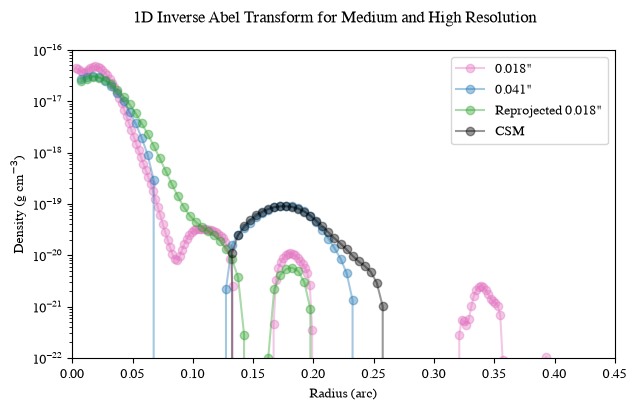

In [ ]:
plot_1d_abel(abels,info3,radius3,ax_ymin=1e-22,ax_ymax=1e-16,xmax=0.3, suptitle = "1D Inverse Abel Transform for Medium and High Resolution")


In [ ]:
def plot_1d_abel_massloss_bkg(data_abel_1d,info,radius,ax_ymin=1e-2, ax_ymax=1e4,xmin=0,xmax=0.45, suptitle = "1D Abel Transformation (g/cm3)", dent=False):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''

    fig, ax = plt.subplots(1, 1, figsize = [7,4])
    fig.suptitle(suptitle)

    title = ['hr','lr','reproj','csm']
    labels = ['{res}"'.format(res = np.round(info['hr']['kspatres'],3)),
             '{res}"'.format(res = np.round(info['lr']['kspatres'],3)),
               'Reprojected {res}"'.format(res = np.round(info['hr']['kspatres'],3)),
                 "CSM"]    
    
    for j in range(len(title)):
        # print(len(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])]))
        # print((data_abel_1d[title[j]]*430).shape)
        ax.fill_between(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])],data_abel_1d[title[j]]+data_abel_1d[title[j]]*430,data_abel_1d[title[j]]+data_abel_1d[title[j]]*1000,alpha=0.4, label = labels[j], color = color[j])
        #ax.plot(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])],data_abel_1d[title[j]]*200,'o-',alpha=0.4, label = labels[j], c = color[j])
            #ax.errorbar(radius[title[c]]['arc_1d'],data_1d[title[c]].value,yerr=info[title[c]]['error'].value, c = color[c])

    x = (radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])]).value
    increment = np.arange(0,len(x),x[1]-x[0])
    #y = (data_abel_1d[title[j]][0]*716)*(10)**(-x) #abels['hr'][0]
    y = (data_abel_1d['lr'][0]*716)*10**(-x)
 

    xlr = (radius[title[j]]['arc_1d'][:len(abels['lr'])]).value    
    xlr_cm = (radius[title[j]]['pc_1d'][:len(abels['lr'])]).to(u.cm)    
    xlr_rsun = (radius[title[j]]['pc_1d'][:len(abels['lr'])]).to(u.Rsun)  
    dlr = np.gradient(abels['lr']*716,0.005)
    # # print("dlr", dlr)
    # # print("y!",716*abels['lr'][0]*10**(dlr*xlr))

    v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)
    v_s = (1e6*u.cm/u.s)

    Mlr = radius3['lr']['pc_1d'].to(u.cm)**2* (716*abels['lr']*u.g/u.cm**3).to(u.M_sun/u.cm**3) *4*np.pi*(1e6*u.cm/u.s).to(u.cm/u.yr)
    
    #ax.plot(xlr, Mlr.to(u.g/u.s) / (4*np.pi*xlr_cm**2*v_s), label = r'$\dot M = 4 \pi r^2 \rho v$')


    mdotexp = [-8,-7,-6,-5,-4]# msun/yr

    for mdot in mdotexp:
        print(mdot)

        rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*xlr_cm**2*v_yr)
        ax.plot(xlr, rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

        xtext = xlr[1]
        ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/13

        print(xtext,ytext)


        ax.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
                rotation=-20, alpha = 0.6)


    # ax.plot(xlr, 716*abels['lr'][0]*10**(dlr*xlr), color = 'gray', ls  = '--', label = 'LR deriv ~10**(-13)')
    ax.legend(loc = 'upper right')#, bbox_to_anchor=(.85, 0.5, 0.5, 0.5))
    ax.semilogy()
    ax.semilogx()
#     ax.set_title("1-D Density (g/cm3)")
    ax.set_xlim(xmin,xmax)
    ax.set_ylim(ax_ymin, ax_ymax)


    ax.set_xlabel('Radius (arcseconds)')
    ax.set_ylabel(r'Density (g cm$^{-3}$)')

-8
0.012500000000001 4.1463906183997455e-18 g / cm3
-7
0.012500000000001 4.1463906183997455e-17 g / cm3
-6
0.012500000000001 4.1463906183997457e-16 g / cm3
-5
0.012500000000001 4.146390618399746e-15 g / cm3
-4
0.012500000000001 4.146390618399746e-14 g / cm3


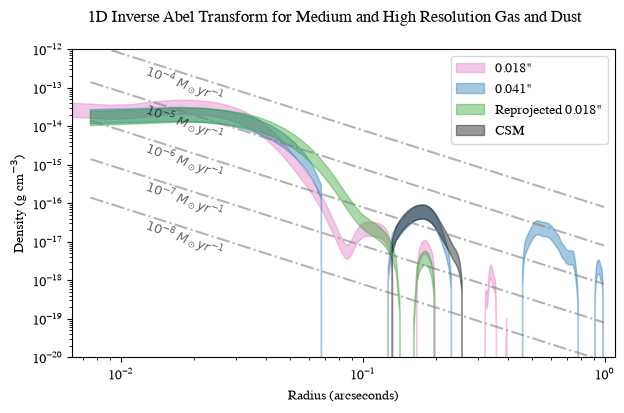

In [ ]:
plot_1d_abel_massloss_bkg(abels,info3,radius3,ax_ymin=1e-20,ax_ymax=1e-12, xmin= 1*10**-2.2,xmax=1.1, suptitle = "1D Inverse Abel Transform for Medium and High Resolution Gas and Dust" ,dent = True)
